# Neural Network Project - Breast Cancer Dataset

The goal of this notebook is to use Scikit-Learn's and from scratch Neural Networks models to implement a complete machine learning project using **Scikit-Learn's breast cancer dataset**.

## 1. Imports

In [1]:
# Imports
import pandas as pd
import numpy as np

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report, roc_curve, auc

import matplotlib.pyplot as plt

import joblib

from neural_network import NeuralNetwork, Layer

## 2. Load dataset

In [2]:
df = pd.DataFrame(load_breast_cancer().data, columns=load_breast_cancer().feature_names)
df['target'] = load_breast_cancer().target # binary classification: malignant or benign

In [3]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
df.info(), df.describe(), df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

(None,
        mean radius  mean texture  mean perimeter    mean area  \
 count   569.000000    569.000000      569.000000   569.000000   
 mean     14.127292     19.289649       91.969033   654.889104   
 std       3.524049      4.301036       24.298981   351.914129   
 min       6.981000      9.710000       43.790000   143.500000   
 25%      11.700000     16.170000       75.170000   420.300000   
 50%      13.370000     18.840000       86.240000   551.100000   
 75%      15.780000     21.800000      104.100000   782.700000   
 max      28.110000     39.280000      188.500000  2501.000000   
 
        mean smoothness  mean compactness  mean concavity  mean concave points  \
 count       569.000000        569.000000      569.000000           569.000000   
 mean          0.096360          0.104341        0.088799             0.048919   
 std           0.014064          0.052813        0.079720             0.038803   
 min           0.052630          0.019380        0.000000            

In [5]:
print("Shape:\n", df.shape)
print("Head:\n", df.head())
print("Description:\n", df.describe())
print("Null Values:\n", df.isnull().sum())

Shape:
 (569, 31)
Head:
    mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  wor

Clean dataset with **no missing values, 30 numerical features and 569 samples**.

We also notice that for the target, the mean is 0.627 meaning that ~63% of samples are class 1 (benign) and ~37% of them Class 0 (malignant). 

The **dataset is slightly imbalanced**. Not critically so, but it means that accuracy alone isn’t a sufficient metric. A model that always predicts 1 would already have 63% accuracy without learning anything.

That’s why we'll also look at precision, recall, and F1 score in the evaluation, especially for class 0 (malignant), where a false negative is clinically dangerous.

## 3. Train and test datasets

In [6]:
# Prepare the data: target variable and features
X = df.drop("target", axis=1).values # features
y = df["target"].values # target

In [7]:
# Split datasets into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Why scaling the features?**

Scaling is essential for a neural network—even more so than for logistic regression.

Two reasons:

1. **Gradient descent**: if features have vastly different scales (e.g., one feature ranges from 0 to 0.001, another from 100 to 1000), the gradients differ greatly in magnitude. The learning rate that works for one feature will ruin the other. Scaling puts everything on the same playing field.

2. **Weight initialization**: Xavier initialization assumes that the inputs have a reasonable variance around 0. If your inputs are on arbitrary scales, this assumption is violated from the very first forward pass.

On the Breast Cancer dataset, this is particularly important because the features vary enormously in scale (cell surface area vs. texture vs. symmetry).

In [8]:
# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Why scaling only features and separating training and test datasets?**

This is called **data leakage**.

If we apply the scaler to the entire dataset (training + test), the calculated mean and standard deviation contain information about the test set. The model has never “seen” the test set directly, but the scaling has taken it into account.

The test set is supposed to simulate unknown future data. In production, we only have the scaler trained on the training set to transform the new data. So that’s exactly what we need to replicate here.

The rule: train on the training set, transform on the training set, and test.

## 4. Train the model with Neural Network model from scratch

In [9]:
# Reshape y 
y_train_nn = y_train.reshape(1, -1)
y_test_nn = y_test.reshape(1, -1)

In [10]:
# Initialize the [30, 16, 8, 1] neural network
np.random.seed(42)
nn = NeuralNetwork(loss='binary')
nn.add(Layer(16, 'relu'))
nn.add(Layer(8, 'relu'))
nn.add(Layer(1, 'sigmoid'))

In [11]:
# Fit and train the model
nn.fit(X_train_scaled, y_train_nn, learning_rate=0.001, n_iterations=10000, random_seed=42)

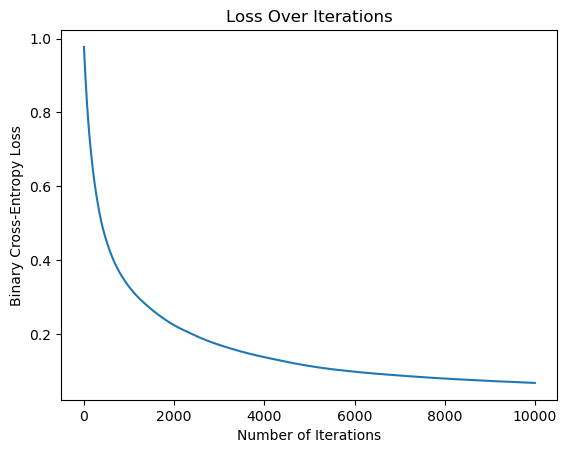

In [12]:
# Visualize loss over iterations (learning curve)
plt.plot(nn.loss_history)
plt.xlabel("Number of Iterations")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Loss Over Iterations")
plt.show()

In [13]:
# Evaluate the scratch model
# Train set evaluation
predictions_scratch_train = nn.predict(X_train_scaled).flatten() 
accuracy_scratch_train = accuracy_score(y_train, predictions_scratch_train)
f1_score_scratch_train = f1_score(y_train, predictions_scratch_train)
recall_scratch_train = recall_score(y_train, predictions_scratch_train)

print("Scratch Neural Network - Train Accuracy:", accuracy_scratch_train)
print("Scratch Neural Network - Train F1 Score:", f1_score_scratch_train)
print("Scratch Neural Network - Train Recall:", recall_scratch_train)

Scratch Neural Network - Train Accuracy: 0.9846153846153847
Scratch Neural Network - Train F1 Score: 0.987783595113438
Scratch Neural Network - Train Recall: 0.9895104895104895


In [14]:
# Test set evaluation
predictions_scratch_test = nn.predict(X_test_scaled).flatten() 
accuracy_scratch_test = accuracy_score(y_test, predictions_scratch_test)
f1_score_scratch_test = f1_score(y_test, predictions_scratch_test)
recall_scratch_test = recall_score(y_test, predictions_scratch_test)

print("Scratch Neural Network - Test Accuracy:", accuracy_scratch_test)
print("Scratch Neural Network - Test F1 Score:", f1_score_scratch_test)
print("Scratch Neural Network - Test Recall:", recall_scratch_test)

Scratch Neural Network - Test Accuracy: 0.9736842105263158
Scratch Neural Network - Test F1 Score: 0.9790209790209791
Scratch Neural Network - Test Recall: 0.9859154929577465


Accuracy (97.3%), f1 (97.1%) and recall for class 1 (benign) (98.5%) scores are very good. 

Note: When comparing these metrics to those obtained using the logistic regression model (see `02_classical_ml/02_logistic_regression/project.ipynb`), we can see that the performance of this neural network is slightly worse than that of logistic regression. 

In [15]:
# Print confusion matrix and classification report for test set
conf_matrix = confusion_matrix(y_test, predictions_scratch_test)
print("Confusion Matrix:\n", conf_matrix)

class_report = classification_report(y_test, predictions_scratch_test)
print("Classification Report:\n", class_report)

Confusion Matrix:
 [[41  2]
 [ 1 70]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Confusion matrix:

- 70 true negatives (malignant cases correctly detected)
- 41 true positives (benign cases correctly detected)
- 1 false positive (a malignant case predicted as benign)
- 2 false negative (a benign case predicted as malignant)

The critical figure here is that 1 false positive (a malignant tumor) that went undetected. 

Recall for class 0 = $\frac{TP}{TP + FN} = \frac{41}{41 + 2} = 0.95$, so we miss 2 malignant case out of 43. That’s very good for a model built from scratch.

## 5. Train Scikit-Learn Multi-layer Perceptron Classifier

In [16]:
# Initialize the [30, 16, 8, 1] neural network
mlp_classifier = MLPClassifier(
    hidden_layer_sizes=(16, 8),  # [30, 16, 8, 1]-layer sizes
    activation='relu',
    solver='sgd',
    learning_rate_init=0.001,
    max_iter=10000,
    random_state=42
)

In [17]:
# Fit and train the neural network
mlp_classifier.fit(X_train_scaled, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(16, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'sgd'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",10000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


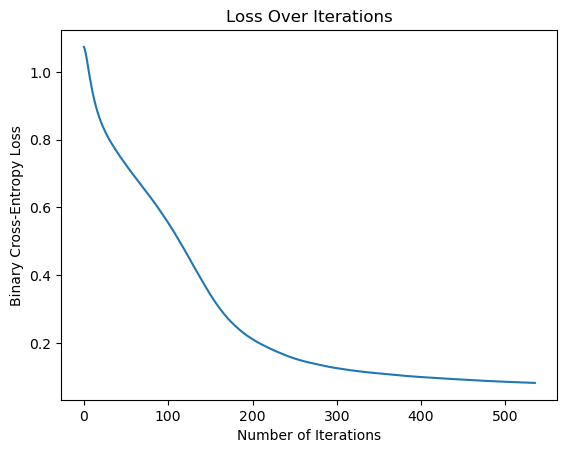

In [18]:
# Visualize loss over iterations (learning curve)
plt.plot(mlp_classifier.loss_curve_)
plt.xlabel("Number of Iterations")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Loss Over Iterations")
plt.show()

In [19]:
# Evaluate sklearn's model
# Train set evaluation
predictions_sklearn_train = nn.predict(X_train_scaled).flatten() 
accuracy_sklearn_train = accuracy_score(y_train, predictions_sklearn_train)
f1_score_sklearn_train = f1_score(y_train, predictions_sklearn_train)
recall_sklearn_train = recall_score(y_train, predictions_sklearn_train)

print("Scikit-Learn MLPClassifier - Train Accuracy:", accuracy_sklearn_train)
print("Scikit-Learn MLPClassifier - Train F1 Score:", f1_score_sklearn_train)
print("Scikit-Learn MLPClassifier - Train Recall:", recall_sklearn_train)

Scikit-Learn MLPClassifier - Train Accuracy: 0.9846153846153847
Scikit-Learn MLPClassifier - Train F1 Score: 0.987783595113438
Scikit-Learn MLPClassifier - Train Recall: 0.9895104895104895


In [20]:
# Test set evaluation
predictions_sklearn_test = nn.predict(X_test_scaled).flatten() 
accuracy_sklearn_test = accuracy_score(y_test, predictions_sklearn_test)
f1_score_sklearn_test = f1_score(y_test, predictions_sklearn_test)
recall_sklearn_test = recall_score(y_test, predictions_sklearn_test)

print("Scikit-Learn MLPClassifier - Test Accuracy:", accuracy_sklearn_test)
print("Scikit-Learn MLPClassifier - Test F1 Score:", f1_score_sklearn_test)
print("Scikit-Learn MLPClassifier - Test Recall:", recall_sklearn_test)

Scikit-Learn MLPClassifier - Test Accuracy: 0.9736842105263158
Scikit-Learn MLPClassifier - Test F1 Score: 0.9790209790209791
Scikit-Learn MLPClassifier - Test Recall: 0.9859154929577465


The results are almost **identical**: 97.3% test accuracy, F1 score of 97.1%, and recall of 98.6% for both models. 

This is perfect validation as our implementation from scratch almost produces exactly the same results as sklearn.

A few observations comparing the sklearn curve to our from scratch:
- Convergence with sklearn model converges in ~330 iterations, compared to 10,000 our from scratch neural network. Two reasons: sklearn uses Adam by default (even with solver=‘sgd’ it optimizes better), and its implementation is numerically more stable.

- Initial loss with sklearn starts at 1.05, and our at ~7.4. The difference comes from the weight initialization, sklearn uses probably a slightly different initialization.

## 6. Dataset and decision boundary visualization

In [21]:
# Compute the probabilities for the test set using the scratch model
y_proba_scratch_test = nn.predict_proba(X_test_scaled)

In [22]:
# Compute the probabilities for the test set using scikit-learn model
y_proba_sklearn_test = mlp_classifier.predict_proba(X_test_scaled)[:, 1]

In [23]:
# ROC curves
# Scratch model
fpr_scratch, tpr_scratch, _ = roc_curve(y_test, y_proba_scratch_test)
auc_scratch = auc(fpr_scratch, tpr_scratch)

# Sklearn model
fpr_sklearn, tpr_sklearn, _ = roc_curve(y_test, y_proba_sklearn_test)
auc_sklearn = auc(fpr_sklearn, tpr_sklearn)

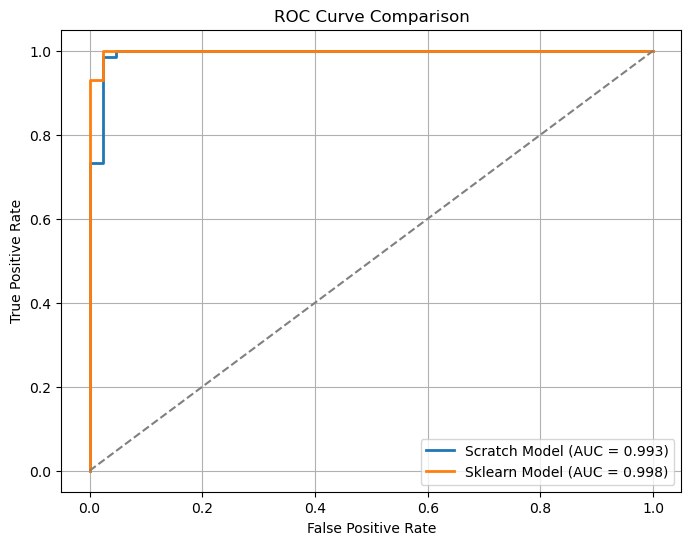

In [24]:
# Plot ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_scratch, tpr_scratch, label=f"Scratch Model (AUC = {auc_scratch:.3f})", linewidth=2)
plt.plot(fpr_sklearn, tpr_sklearn, label=f"Sklearn Model (AUC = {auc_sklearn:.3f})", linewidth=2)

# Add a diagonal line for reference (random classifier)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

We obtain very good results: AUC 0.991 for the scratch model vs. 0.998 for sklearn. 

The difference is minimal and can be explained by the optimizer: sklearn uses Adam internally, which converges better, while your implementation uses classical stochastic gradient descent (SGD).

Both curves are in the top-left quadrant, meaning both models have excellent ability to distinguish between malignant and benign cases.

## 7. Save models

In [25]:
# Save both models
joblib.dump(nn, "models/neural_network_classifier_scratch.pkl")
joblib.dump(mlp_classifier, "models/mlp_classifier_sklearn.pkl")

['models/mlp_classifier_sklearn.pkl']

In [26]:
# Verify that the models are saved correctly
loaded_scratch_model = joblib.load("models/neural_network_classifier_scratch.pkl")
loaded_sklearn_model = joblib.load("models/mlp_classifier_sklearn.pkl")

In [27]:
# Predict the test set with the loaded models
predictions_loaded_scratch = loaded_scratch_model.predict(X_test_scaled).flatten()
predictions_loaded_sklearn = loaded_sklearn_model.predict(X_test_scaled)

In [28]:
accuracy_loaded_scratch = accuracy_score(y_test, predictions_loaded_scratch)
accuracy_loaded_sklearn = accuracy_score(y_test, predictions_loaded_sklearn)

print("Loaded scratch accuracy:", accuracy_loaded_scratch)
print("Loaded sklearn accuracy:", accuracy_loaded_sklearn)

Loaded scratch accuracy: 0.9736842105263158
Loaded sklearn accuracy: 0.9824561403508771


In [29]:
# Compare predictions from loaded models with original predictions
np.allclose(predictions_scratch_test, predictions_loaded_scratch), np.allclose(predictions_sklearn_test, predictions_loaded_sklearn)

(True, False)

In [30]:
# Save the scalar to perform during predictions the exact transformation
joblib.dump(scaler, "models/scaler.pkl")

['models/scaler.pkl']